In [2]:
import os
import re
import math
import pickle
import random as rd
from tqdm import tqdm
from typing import Iterator, Tuple, Callable

from my_transformations import apply_transformation

import cv2
import pillow_heif
from PIL import Image

import jiwer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tokenizers
import transformers
from tokenizers import trainers, processors, pre_tokenizers

import torch
import torchvision
import torchsummary
from torch.nn import utils
from torch.utils import data
from torchvision import io, transforms
from torchvision.transforms import functional
from torch import nn, optim, onnx, distributions

#adding ability to open heic images
pillow_heif.register_heif_opener()

In [3]:
#global parameters
D_MODEL = 256
N_HEADS = 4
NUM_LAYERS = 3
FFN_DIM = 1024

In [4]:
#checking cuda
torch.cuda.is_available()

True

In [4]:
model = torchvision.models.resnet18(weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1, progress = True)
#display forward propogation of initial resnet
torchsummary.summary(model, (3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

In [5]:
resnet_without_last_two = nn.Sequential(*list(model.children())[:-2])
#display forward propogation of resnet without average pooliing and linear head
torchsummary.summary(resnet_without_last_two, (3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

In [6]:
for name, parameter in resnet_without_last_two.named_parameters():
    if name.split('.')[0] != '7':
        parameter.requires_grad = False

In [7]:
#see if we can freeze weights of all functions
for name, parameter in resnet_without_last_two.named_parameters():
    print(name.split('.')[0], parameter.requires_grad)

0 False
1 False
1 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True


In [8]:
last_child = list(resnet_without_last_two.children())[-1]
last_child

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1

In [5]:
def resnet_trans(pil_image):
    """
    Parameters
    ----------
    pil_image: image opend with pillow library 
    
    returns
    ----------
    Tensor image transformed for ResNet; with dtype float32
    """
    #apply necessary transformations for ResNet
    data_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224,224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return data_transforms(pil_image.convert('RGB'))

In [6]:
def get_tokenizer_object(words_iterable):
    """
    Parameters
    ----------
    Iterable of words

    returns
    -------
    a tokenizer object that implements all the necessary 
    special tokens additions

    Description
    ------------
    Takes in an iterable of words and returns a HF tokenizer object over them
    that appends all the necessary special tokens

    Note
    -----
    The tokenizer would expect the words that have single spaces between the letters
    example: 'cat' --> 'c a t'
    """
    #get maximum length of words
    max_length = 0
    for word in words_iterable:
        max_length = max(max_length,len(word))
    #adding 2 for sos and eos tokens 
    max_length += 2
    #creating words with spaces between letters
    main_iterable_of_words = [' '.join([letter for letter in word]) for word in words_iterable]
    #specifiing tokenizer parameters
    tokenizer_obj = tokenizers.Tokenizer(model=tokenizers.models.WordLevel(unk_token='<unk>'))
    tokenizer_obj.pre_tokenizer = pre_tokenizers.Whitespace()
    tokenizer_obj.post_processor = processors.TemplateProcessing(single="<sos> $A <eos>", special_tokens=[('<sos>',2), ('<eos>',3)])
    #enabling padding with maximun length
    tokenizer_obj.enable_padding(direction='right', pad_id = 0, pad_token='<pad>', length=max_length)
    #training tokenizer object
    tokenizer_trainer = trainers.WordLevelTrainer(vocab_size=100, special_tokens=['<pad>','<unk>','<sos>','<eos>'])
    tokenizer_obj.train_from_iterator(iterator=main_iterable_of_words, trainer=tokenizer_trainer)
    #transformers tokenizer
    transformers_tokenizer = transformers.PreTrainedTokenizerFast(tokenizer_object = tokenizer_obj)
    return transformers_tokenizer, max_length

In [7]:
#here I also have to add a class of picture distribution for further stratification
def get_dataset(path_to_folder = '/home/luchian/all_data/datasets/Image_data.v4'):
    """
    Parameters
    ----------
    An absolute path to folder with dataset
    
    returns
    --------
    a dataframe that has the column names [div, image_path, target]
    with corresponding data (div is column that helps devide data)

    Description
    ------------
    Takes in an absolute path to a folder that contains data in the form
    folder_with_target_name[images]
    i.e. each target has a folder of its name with images in it belonging to that target
    """
    #create a dataframe
    main_frame = pd.DataFrame(columns=['Div','ImagePath','Target'])
    #get target folders
    list_of_target_folders = os.listdir(path_to_folder)
    #for each target folder get the images with that target
    for target_name in list_of_target_folders:
        target_data = target_name.strip().split('.')
        images = os.listdir(path_to_folder+'/'+target_name)
        pd_frame = pd.DataFrame({'Div':[target_data[0] for _ in range(len(images))],'ImagePath':[path_to_folder+'/'+target_name+'/'+image_path for image_path in images], 'Target':[target_data[1] for _ in range(len(images))]})
        #ignore index to make shure we have regular indexing order 
        main_frame = pd.concat([main_frame, pd_frame], ignore_index=True)
    return main_frame

In [8]:
#checking that everything is allright with the dataset
the_set = get_dataset()
the_set

,Div,ImagePath,Target
0,0,/home/luchian/all_data/datasets/Image_data.v4/...,mustofcoursekeepouttheamericanswere
1,0,/home/luchian/all_data/datasets/Image_data.v4/...,aneardisastrousleakfamiliarmembersofbritains
2,0,/home/luchian/all_data/datasets/Image_data.v4/...,itwaslockedeagerfingersfeltbulkycontentsand
3,0,/home/luchian/all_data/datasets/Image_data.v4/...,mrmacmillanexplainedthathehaddeliber
4,0,/home/luchian/all_data/datasets/Image_data.v4/...,termrlloydandhis24strongdelegationlanded
...,...,...,...
10572,0,/home/luchian/all_data/datasets/Image_data.v4/...,crampedandprimitiveexistence
10573,2,/home/luchian/all_data/datasets/Image_data.v4/...,chargedtheirelectricbatteries
10574,1,/home/luchian/all_data/datasets/Image_data.v4/...,therewereanythinginqueensregulationstocoverthis
10575,2,/home/luchian/all_data/datasets/Image_data.v4/...,andifcertaindishesandmodesoffoodhave


In [9]:
the_set['Target'].isna().astype(int).sum().item()

0

In [10]:
#checking whethere there are no spaces in targets
for one_target in the_set['Target']:
    splitted_target = one_target.split(' ')
    splitted_len = len(splitted_target)
    if splitted_len != 1:
        print(one_target)
        break
#OK

In [11]:
def pos_embeds(embedding_matrix, dev='cpu'):
    """
    Parameters
    ----------
    embedding matrix: torch.Tensor of shape (batch_size, seq_len, embedding_dim)

    returns
    -------
    embedding matrix + positional encoding
    same embedding matrix with added positional embeddings
    """
    batch_size, seq_len, d_model = embedding_matrix.size()
    position = torch.arange(seq_len, device=dev).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2, device=dev) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model, device=dev)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return embedding_matrix + pe.unsqueeze(0)

In [12]:
def make_spaces(word):
    """Makes spaces between the letter of a given word"""
    return ' '.join(list(word))

In [13]:
def padding(tensor:torch.tensor, max_length:int, pad_value:int) -> torch.tensor:
    """Given a 1-d tensor and an integer max_length returns 1-d tensor padded to max_length with pad_value"""
    padded_tensor = torch.zeros(max_length).to(dtype=tensor.dtype) + torch.tensor(pad_value).to(dtype=tensor.dtype)
    for i in range(len(tensor)):
        padded_tensor[i] = tensor[i]
    return padded_tensor

In [14]:
class TextRecDataset(data.Dataset):
    """Implements dataset for Text Recognition with online augmentation"""
    def __init__(self, dataset:pd.DataFrame, tokenizer:transformers.PreTrainedTokenizerFast, max_length:int, pad_id:int, word_processor=make_spaces, picture_processor=resnet_trans):
        #main parameters
        self.dataset = dataset
        self.max_length = max_length
        self.pad_id = pad_id
        self.tokenizer = tokenizer
        #processors for words and pictures
        self.word_processor = word_processor
        self.picture_processor = picture_processor

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indx):
        #getting image path and target name
        data_indx_row = self.dataset.iloc[indx,:]
        image_path = data_indx_row['ImagePath']
        target_name = data_indx_row['Target']
        #maing image to go through augmentations
        main_image = Image.open(image_path).convert("RGB")
        image_transforms = [img.convert("RGB") for img in apply_transformation(main_image)]
        #iterating over obtained images and applying resnet transformations and converting to necessary formats (Tensors)
        images_to_cat = []
        targets_to_cat_y = []
        targets_to_cat_z = []
        for one_image in image_transforms:
            tensor_image = self.picture_processor(one_image).unsqueeze(dim = 0)
            images_to_cat.append(tensor_image)
        #target names to tensors with a given tokenizer 
        target_ids = torch.tensor(self.tokenizer(self.word_processor(target_name)).input_ids, dtype=torch.long)
        target_ids_y = padding(target_ids[:-1], max_length=self.max_length, pad_value=self.pad_id)
        target_ids_z = padding(target_ids[1:], max_length=self.max_length, pad_value=self.pad_id)
        #appending targets
        for _ in range(len(images_to_cat)):
            targets_to_cat_y.append(target_ids_y.unsqueeze(dim=0))
            targets_to_cat_z.append(target_ids_z.unsqueeze(dim=0))
        #returning with concatenation
        return torch.cat(images_to_cat, dim=0), torch.cat(targets_to_cat_y, dim=0), torch.cat(targets_to_cat_z, dim=0)

In [15]:
class ValidationDataset(data.Dataset):
    def __init__(self, dataset:pd.DataFrame):
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indx):
        data_indx_row = self.dataset.iloc[indx,:]
        return Image.open(data_indx_row['ImagePath']), data_indx_row['Target']

In [16]:
#Enocder-Decoder model for TextRecognition 
class TRModel(nn.Module):
    def __init__(self, vocabulary_size, ffn_dim=FFN_DIM, d_model=D_MODEL, nhead=N_HEADS, num_layers=NUM_LAYERS, dropout=0.5, padding_indx=0, device='cpu', train=True, freeze_params=30):
        super().__init__()
        self.device = device
        #Encoder
        #load ResNet with last two linear layers removed
        self.encoder = nn.Sequential(*list(torchvision.models.resnet18(weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1, progress = False).children())[:-2])
        #freeze some layesr
        count = 0
        for parameter in self.encoder.parameters():
            if count > freeze_params:
                break
            parameter.requires_grad = False
            count += 1

        #linear head that project to embedding dimension
        self.linear_encoder_head = nn.Linear(512,d_model)

        #Decoder
        #embedding layer
        self.embed_layer = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=d_model, padding_idx=padding_indx)
        self.decoder_layer = nn.TransformerDecoderLayer(dim_feedforward=ffn_dim, d_model=d_model, nhead=nhead, dropout=dropout)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=num_layers)

        #linear head over vocabulary
        self.linear_head = nn.Linear(d_model,vocabulary_size)
    
    def generate_mask(self,N):
        """Generates a mask for transformer decoder self-attention"""
        mask = (torch.triu(torch.ones(N,N)) == 1).transpose(0,1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x_pic_tensor, x_letter_ids):
        """
        parameters
        ----------
        x_pic: tensor of shape batch_size X channels X H x W
        x_text: tensor of shape seq_len X batch_size X d_model (embed_dim)
        """
        encoder_forward = self.encoder(x_pic_tensor)
        encoder_forward = encoder_forward.reshape(encoder_forward.shape[0], encoder_forward.shape[1], -1)
        #reshape to shape (batch_size, spatial_sequence_len, num_channels)
        encoder_forward = encoder_forward.transpose(1,2)
        #projecting number of channels to d_model shape
        encoder_forward = self.linear_encoder_head(encoder_forward)
        #adding positional embeddings
        encoder_forward = pos_embeds(encoder_forward, dev=self.device)
        #reshaping to shape (seq_len, batch_size, embed_dim (d_model))
        encoder_forward = encoder_forward.transpose(0,1)
        
        #getting vector embeddings
        letter_embeds = self.embed_layer(x_letter_ids) 
        #add positional embeddings and reshaping to seq_len first
        letter_embeds = pos_embeds(letter_embeds, dev=self.device).transpose(0,1)
        seq_len = letter_embeds.shape[0]
        #creating a mask for decoder forwarding
        tgt_mask = self.generate_mask(seq_len).to(self.device)
        #going through decoder
        decoder_forward = self.decoder(letter_embeds, memory=encoder_forward, tgt_mask=tgt_mask)
        clf_head = self.linear_head(decoder_forward)
        return clf_head

In [17]:
#metrics for OCR problem
def total_accuracy(string_array:np.array) -> float:
    """
    parameters
    ----------
    string_array:np.array 
        2-dimensional array of shape (N, 2) where N is number of samples
        first column is ground truth strings, second - prediction strings
    
    returns
    -------
    accuracy:float
        accuracy counted by the number of 100% matchings
    """
    truth_row = string_array[:,0]
    prediction_row = string_array[:,1]
    number_of_matches = (truth_row==prediction_row).astype(np.int64).sum()
    return (number_of_matches/string_array.shape[0]).item()

def cer_metric(string_array:np.array) -> float:
    """
    parameters
    ----------
    string_array:np.array 
        2-dimensional array of shape (N, 2) where N is number of samples
        first column is ground truth strings, second - prediction strings
    
    returns
    -------
    accuracy:float
        average CER metrics over all dataset
    """
    return np.apply_along_axis(lambda x: jiwer.cer(x[0].item(), x[1].item()), axis=1, arr=string_array).mean().item()

In [18]:
def get_metrics(val_dataset:data.Dataset, model:nn.Module, tokenizer:transformers.PreTrainedTokenizerFast, inference:Callable) -> Tuple[float,float]:
    """
    description
    -----------
    Given a validation dataset and a model returns CER and word accuracy metrics

    parameters
    ----------
    val_dataset:torch.utils.data.dataset
        dataset that returns a tuple of the form (pil image, target)

    model:nn.Module 
        Trained model that is going to make predictions
    
    tokenizer:transformers.PreTrainedTokenizerFast
        tokenzer for the model to decode predictions into the strings
    
    inference:Callable
        function that takes in model, tokenizer, word transform, picture transform and makes a prediction given the pillow picture
        argument order of inference: pillow picture, model, tokenizer, word transform (defaulted), picture transform (defaulted), device (defaulted), character generation limit 
    
    returns
    -------
    CER metric: float
    Total matches accuracy: float
    """
    #the lists for true and generated string values 
    true_strings = []
    generated_strings = []
    #iterating over validation and updating the lists
    for one_sample in tqdm(val_dataset):
        generated_string = inference(one_sample[0], model=model, tokenizer=tokenizer, limit=len(one_sample[1]))
        true_string = one_sample[1]
        #appending values
        true_strings.append(true_string)
        generated_strings.append(generated_string)
    #making numpy arrays of true and generated values of shape (N_samples, 2) for calculating metrics
    numpy_true_pred_values = np.array([true_strings, generated_strings]).T
    CER, ACCURACY = cer_metric(numpy_true_pred_values), total_accuracy(numpy_true_pred_values)
    return CER, ACCURACY

In [19]:
def model_inference(pillow_picture, model, tokenizer, on_context=False, pictures_context=None, targets_context=None, word_transform=make_spaces, picture_transform=resnet_trans, device='cuda', limit=100):
    """
    Description
    -----------
    Given an image returns generated text
    """
    if on_context:
        model.train()
        y_pred = model(x_pic_tensor=pictures_context, x_letter_ids=targets_context)
        return y_pred
    else:
        #change model state to evaluation
        model.eval()
        #transform picture for forward pass
        tensor_picture = picture_transform(pillow_picture).unsqueeze(dim=0).to(device=device)
        #creating starting sequence
        sequence = ''
        #while last token does not equal to eos or limit achieved keep generating
        iter_count = 0
        while True and iter_count < limit:
            #update count
            iter_count += 1
            sequence_tensor = torch.tensor(tokenizer(word_transform(sequence)).input_ids[:-1]).reshape(1,-1).to(device=device)
            y_pred = model(x_pic_tensor=tensor_picture, x_letter_ids=sequence_tensor).squeeze(dim=1)[-1].softmax(dim=0) #choose the last token probabilities
            #make distribution over vocabulary tokens
            dist_prob = distributions.Categorical(probs=y_pred)
            #sample next token
            next_sampled_token = dist_prob.sample().detach().cpu().item()
            #if we reached the last token we break (else continute)
            if next_sampled_token == tokenizer._tokenizer.get_vocab()['<eos>']:
                break
            else:
                #add new token
                sequence += tokenizer._tokenizer.id_to_token(next_sampled_token)
        return sequence

In [20]:
class EarlyStopping(object):
    def __init__(self, patience, epoch_multiplier):
        #main parameters
        self.patience = patience
        self.epoch_multiplier = epoch_multiplier
        #in-training parameters
        self.count = 0
        self.criterion_list = []
        #total number of epochs needed for training
        self.total_epochs = None
        #keeping track of max value of anomaly count
        self.max_anomaly = 0
    
    def add(self, crit_value):
        self.count += 1
        self.criterion_list.append(crit_value)

    def stopping(self):
        anomaly_count = 0
        #counting number of unwanted criterion increases
        for back_ind in range(-1,-(min(self.patience+2,len(self.criterion_list)-1)),-1):
            if self.criterion_list[back_ind] > self.criterion_list[back_ind-1]:
                anomaly_count += 1
            else:
                #updating anomaly count
                self.max_anomaly = max(self.max_anomaly, anomaly_count)
                anomaly_count = 0
                break
        #if the number of anomaly is larger than patience stop else continue
        if anomaly_count > self.patience:
            self.total_epochs = self.count * self.epoch_multiplier
            return True
        else:
            return False

In [ ]:
def train_model(model, train_loader, epoch:int|float, main_optim, scheduler, main_loss, print_every=1, dev='cpu', early_stop=False, patience=10, epoch_multiplier=10, validation_dataset=None, inference=None,
                names=None, model_dist_prob=1.00, decay_rate_model_dist=0.005, lower_bound_loss=0.3, min_teacher_forcing=0.5):
    """
    Given training parameters trains the model
    """
    #prepare early stopping class if needed
    if early_stop:
        early_stopping = EarlyStopping(patience=patience, epoch_multiplier=epoch_multiplier)
    #if epoch is infinity we iterate infinitely
    if type(epoch) == float:
        epoch = 10**10
    #Handling KeyBoardInterrupt exception error
    try:
        train_losses = []
        #Going through epochs
        for ep in range(epoch):
            #updating model distribution probability
            model_dist_prob = max(min_teacher_forcing, model_dist_prob-decay_rate_model_dist*(ep+1))
            model.train()
            #we are going to save the mean of losses
            epoch_losses = []
            for X,y,z in tqdm(train_loader, desc=f'Going through the loader on epoch #{ep+1}'):
                #preparing for forward propogation
                X,y,z = X.to(device = dev).reshape(-1,3,224,224), y.to(device = dev).reshape(-1,y.shape[2]), z.to(device = dev).reshape(-1,z.shape[2])
                main_optim.zero_grad()
                #getting indcies that we are going to get from the model inference
                from_model_target_inds = (torch.from_numpy(np.random.random(size=y.shape[1]-1)) > model_dist_prob).to(dtype=torch.long).argwhere().flatten() + 1
                #iterating through these indicies if any
                for ind in from_model_target_inds:
                    y_to_inf = y[:,:ind]
                    inf_pred = model_inference(0, model, train_loader.dataset.tokenizer, on_context=True, pictures_context=X, targets_context=y_to_inf)
                    #preparationfor column insertion
                    inf_pred = inf_pred.transpose(0,1)[:,-1,:].argmax(dim=-1)
                    #changing for prediction
                    y[:,ind] = inf_pred
                #reshape prediction and true values to go through loss
                y_pred = model(x_pic_tensor=X, x_letter_ids=y).transpose(0,1).transpose(1,2)
                the_loss = main_loss(y_pred, z)
                #backprop and clipping
                the_loss.backward()
                main_optim.step()
                #scheduler step
                if scheduler != None:
                    scheduler.step()
                #keep track of losses
                epoch_losses.append(the_loss.item())
            #for each epoch we append the mean loss over that epoch
            avg_epoch_loss = np.array(epoch_losses).mean().item()
            train_losses.append(round(avg_epoch_loss,5))
            #if loss is larger than lower_bound_loss model dist prob cannot go lower than 0.9
            if lower_bound_loss < avg_epoch_loss:
                model_dist_prob = max(0.9, model_dist_prob)
            #updating early loss data
            if early_stop:
                if ep%early_stopping.epoch_multiplier == 0:
                    #calculaing and printing metrics
                    cer, accuracy = get_metrics(validation_dataset, model, train_loader.dataset.tokenizer, inference=inference)
                    print(f'Epoch #{ep+1} | Test CER: {cer} | Test Accuracy: {accuracy}', end = '\n\n')
                    early_stopping.add(cer)
                    if early_stopping.stopping():
                        print('Stopped due to early stopping')
                        break
            #deciding when to actually print losses and other data
            if ep%print_every == 0:
                print(f'Model_inference_probability: {model_dist_prob}')
                print(f'Epoch #{ep+1} | Train loss: {train_losses[-1]}',end = '\n\n')
                #each time we print data we also save necessary data
                #train losses
                with open('/home/luchian/all_data/ML_models_artifacts/'+names['train_losses_name']+'.pkl', 'wb') as file:
                    pickle.dump(train_losses, file)
                #early stopping object
                if early_stop:
                    with open('/home/luchian/all_data/ML_models_artifacts/'+names['early_stopping_name']+'.pkl', 'wb') as file:
                        pickle.dump(early_stopping, file)
                #optimizer
                torch.save(main_optim.state_dict(), f='/home/luchian/all_data/ML_models_artifacts/'+names['optimizer_name']+'.pth')
                #model weights
                torch.save(model.state_dict(), f = '/home/luchian/all_data/ML_models_weights/'+names['model_name']+'.pth')
        return train_losses, early_stopping
    except KeyboardInterrupt:
        return train_losses, early_stopping

In [22]:
pd_dataset = get_dataset()
#split for train and test using Div column in the set
#when already splitted drop the div column and upddte index
pd_dataset_train = pd_dataset[pd_dataset['Div'] == '0'].drop(['Div'], axis=1).reset_index().drop(['index'], axis=1)
pd_dataset_val = pd_dataset[pd_dataset['Div'] == '1'].drop(['Div'], axis=1).reset_index().drop(['index'], axis=1)
pd_dataset_test = pd_dataset[pd_dataset['Div'] == '2'].drop(['Div'], axis=1).reset_index().drop(['index'], axis=1)

In [23]:
pd_dataset

,Div,ImagePath,Target
0,0,/home/luchian/all_data/datasets/Image_data.v4/...,mustofcoursekeepouttheamericanswere
1,0,/home/luchian/all_data/datasets/Image_data.v4/...,aneardisastrousleakfamiliarmembersofbritains
2,0,/home/luchian/all_data/datasets/Image_data.v4/...,itwaslockedeagerfingersfeltbulkycontentsand
3,0,/home/luchian/all_data/datasets/Image_data.v4/...,mrmacmillanexplainedthathehaddeliber
4,0,/home/luchian/all_data/datasets/Image_data.v4/...,termrlloydandhis24strongdelegationlanded
...,...,...,...
10572,0,/home/luchian/all_data/datasets/Image_data.v4/...,crampedandprimitiveexistence
10573,2,/home/luchian/all_data/datasets/Image_data.v4/...,chargedtheirelectricbatteries
10574,1,/home/luchian/all_data/datasets/Image_data.v4/...,therewereanythinginqueensregulationstocoverthis
10575,2,/home/luchian/all_data/datasets/Image_data.v4/...,andifcertaindishesandmodesoffoodhave


In [24]:
print(len(pd_dataset_train))
pd_dataset_train.head(3)

6643


,ImagePath,Target
0,/home/luchian/all_data/datasets/Image_data.v4/...,mustofcoursekeepouttheamericanswere
1,/home/luchian/all_data/datasets/Image_data.v4/...,aneardisastrousleakfamiliarmembersofbritains
2,/home/luchian/all_data/datasets/Image_data.v4/...,itwaslockedeagerfingersfeltbulkycontentsand


In [25]:
print(len(pd_dataset_val))
pd_dataset_test.head(3)

1020


,ImagePath,Target
0,/home/luchian/all_data/datasets/Image_data.v4/...,regardshimselfasinsignificantasthe
1,/home/luchian/all_data/datasets/Image_data.v4/...,givemearingatthisnumberandill
2,/home/luchian/all_data/datasets/Image_data.v4/...,lilyanremonstratedtheywanttobe


In [26]:
print(len(pd_dataset_test))
pd_dataset_test.head(3)

2914


,ImagePath,Target
0,/home/luchian/all_data/datasets/Image_data.v4/...,regardshimselfasinsignificantasthe
1,/home/luchian/all_data/datasets/Image_data.v4/...,givemearingatthisnumberandill
2,/home/luchian/all_data/datasets/Image_data.v4/...,lilyanremonstratedtheywanttobe


In [27]:
tokenizer_object, max_length = get_tokenizer_object(pd_dataset_train['Target'])
tokenizer_object

PreTrainedTokenizerFast(name_or_path='', vocab_size=40, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<sos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [28]:
sanity_check_dataset = pd_dataset_train.sample(10)
sanity_check_dataset

,ImagePath,Target
706,/home/luchian/all_data/datasets/Image_data.v4/...,warbrokeoutin1914ispentmysummerholidaystherean...
2856,/home/luchian/all_data/datasets/Image_data.v4/...,difficultyinbreedingfruitfliesandafter
500,/home/luchian/all_data/datasets/Image_data.v4/...,crowdhadcollectedtherewerefiremen
277,/home/luchian/all_data/datasets/Image_data.v4/...,areportonhistalkswithmrmacmillan
106,/home/luchian/all_data/datasets/Image_data.v4/...,maladynoneofthenumerousconventionalremedies
344,/home/luchian/all_data/datasets/Image_data.v4/...,thepresidentwillprobablydiscussthe
3940,/home/luchian/all_data/datasets/Image_data.v4/...,forhimalthoughsomethinkhisposition
1298,/home/luchian/all_data/datasets/Image_data.v4/...,areparentsorevengrandparents
139,/home/luchian/all_data/datasets/Image_data.v4/...,canbesterilizedorwashedbymachine
346,/home/luchian/all_data/datasets/Image_data.v4/...,whichisagreatresourcevesuviusseems


In [29]:
#save tokenizer object
# with open('/home/luchian/all_data/ML_models_artifacts/eng_char_nums_tokenizer.pkl', 'wb') as file:
#     pickle.dump(tokenizer_object, file)

In [ ]:
TorchDatasetTrain = TextRecDataset(pd_dataset_train, tokenizer=tokenizer_object, max_length=max_length, pad_id=0, picture_processor=resnet_trans)
TorchDatasetVal = ValidationDataset(pd_dataset_val)
TorchDatasetTest = ValidationDataset(pd_dataset_test)

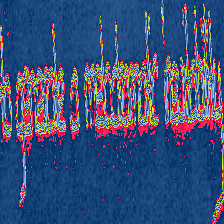

In [31]:
rand_num = rd.randint(0,len(TorchDatasetTrain)-1)
data_sample = TorchDatasetTrain[rand_num]
transforms.ToPILImage()(data_sample[0][0].squeeze(dim=0))

sayinghereisobviousitfollowsnaturally


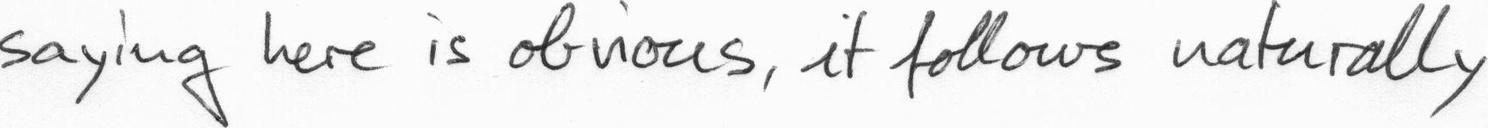

In [32]:
print(TorchDatasetTest[7][1])
TorchDatasetTest[7][0]

In [37]:
data_sample[1]

tensor([[ 2, 22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,
          7, 10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2, 22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,
          7, 10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2, 22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,
          7, 10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 2, 22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,
          7, 10,  4, 13,  8, 25,  4,  6,

In [38]:
data_sample[2]

tensor([[22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,  7,
         10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  3,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,  7,
         10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  3,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,  7,
         10,  4, 13,  8, 25,  4,  6, 20,  7, 14,  3,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [22,  4,  6, 10,  7, 10,  5, 21,  7, 13,  6,  5,  4, 10,  6, 11, 16,  7,
         10,  4, 13,  8, 25,  4,  6, 20,

In [ ]:
model = TRModel(vocabulary_size=TorchDatasetTrain.tokenizer._tokenizer.get_vocab_size(), dropout=0.5, device='cuda', freeze_params=15).to(device = 'cuda')
#torch loading model weights
# model.load_state_dict(torch.load('/home/luchian/all_data/ML_models_weights/04-11-2025_TextRec_6000_1000_3_LAYER_weights_v1.0.pth'))

<All keys matched successfully>

In [ ]:
#train
epoch = float('inf')
batch_size = 16
lr = 9e-4
loader = data.DataLoader(dataset=TorchDatasetTrain, shuffle=True, batch_size=batch_size)
optimizer = optim.Adam(params=model.parameters(), lr=lr, betas=(0.99,0.99))
#loading optimizer weights
# optimizer.load_state_dict(torch.load('/home/luchian/all_data/ML_models_artifacts/04-11-2025_TextRec_6000_1000_3_LAYER_optimizer_v1.0.pth'))
criterion = nn.CrossEntropyLoss(reduction='mean', ignore_index=0, label_smoothing=0.01)

In [41]:
#weights from google colab training
# model.load_state_dict(torch.load('/home/luchian/all_data/ML_models_weights/TRAINING_ARTIFACTS27-10-2025_TextRec_200_weights_v1.4.pth'))
# optimizer.load_state_dict(torch.load('/home/luchian/all_data/ML_models_weights/TRAINING_ARTIFACTS27-10-2025_TextRec_200_optimizer_v1.4.pth'))

In [42]:
sample = next(iter(loader))
print(sample[0].shape)
print(sample[1].shape)

torch.Size([8, 10, 3, 224, 224])
torch.Size([8, 10, 64])


In [35]:
names_dict = {
    'train_losses_name':'07-11-2025_TextRec_6000_1000_3_LAYER_train_losses_v1.1',
    'early_stopping_name':'07-11-2025_TextRec_6000_1000_3_LAYER_early_stopping_object_v1.1',
    'model_name':'07-11-2025_TextRec_6000_1000_3_LAYER_weights_v1.1',
    'optimizer_name':'07-11-2025_TextRec_6000_1000_3_LAYER_optimizer_v1.1'
}

In [38]:
results = train_model(model = model,
                      train_loader = loader,
                      epoch = epoch,
                      main_optim = optimizer,
                      scheduler=None,
                      main_loss = criterion,
                      print_every = 5,
                      dev = 'cuda',
                      names = names_dict,
                      patience=2,
                      epoch_multiplier=2,
                      early_stop=True,
                      validation_dataset=TorchDatasetVal,
                      inference=model_inference,
                      decay_rate_model_dist=0.005,
                      lower_bound_loss=0.35,
                      model_dist_prob=9.0)   

100%|██████████| 1020/1020 [03:20<00:00,  5.08it/s]


Epoch #1 | Test CER: 0.696941593293271 | Test Accuracy: 0.0

Model_inference_probability: 8.995
Epoch #1 | Train loss: 0.5191



100%|██████████| 1020/1020 [03:16<00:00,  5.19it/s]


Epoch #3 | Test CER: 0.6968775952247104 | Test Accuracy: 0.000980392156862745



100%|██████████| 1020/1020 [03:14<00:00,  5.24it/s]


...

Epoch #9 | Test CER: 0.6940341238799934 | Test Accuracy: 0.0



100%|██████████| 1020/1020 [03:12<00:00,  5.29it/s]


Epoch #11 | Test CER: 0.6973818035482466 | Test Accuracy: 0.000980392156862745

Model_inference_probability: 8.67
Epoch #11 | Train loss: 0.4469



100%|██████████| 1020/1020 [03:14<00:00,  5.25it/s]

Epoch #13 | Test CER: 0.6978976655031165 | Test Accuracy: 0.0

Stopped due to early stopping


In [40]:
results = train_model(model = model,
                      train_loader = loader,
                      epoch = epoch,
                      main_optim = optimizer,
                      scheduler=None,
                      main_loss = criterion,
                      print_every = 5,
                      dev = 'cuda',
                      names = names_dict,
                      patience=2,
                      epoch_multiplier=2,
                      early_stop=True,
                      validation_dataset=TorchDatasetVal,
                      inference=model_inference,
                      decay_rate_model_dist=0.005,
                      lower_bound_loss=0.45,
                      model_dist_prob=0.8)   

100%|██████████| 1020/1020 [03:19<00:00,  5.12it/s]


Epoch #1 | Test CER: 0.7120697107091408 | Test Accuracy: 0.000980392156862745

Model_inference_probability: 0.9
Epoch #1 | Train loss: 0.49434



100%|██████████| 1020/1020 [03:17<00:00,  5.18it/s]


Epoch #3 | Test CER: 0.6954012134340111 | Test Accuracy: 0.0



100%|██████████| 1020/1020 [03:20<00:00,  5.09it/s]


...

100%|██████████| 1020/1020 [03:20<00:00,  5.09it/s]


Epoch #15 | Test CER: 0.7095165201517397 | Test Accuracy: 0.000980392156862745



Going through the loader on epoch #16: 100%|██████████| 416/416 [49:04<00:00,  7.08s/it]


Model_inference_probability: 0.6750000000000002
Epoch #16 | Train loss: 0.42613



Going through the loader on epoch #17:  38%|███▊      | 160/416 [22:57<36:44,  8.61s/it]


In [53]:
#changd lr in Adam from 6e-5 to 9e-5

In [ ]:
#torch load state dits of model
# model.load_state_dict(torch.load(f='/home/luchian/all_data/ML_models_weights/TexRec_100_25-10-2025_v1.pth'))

<All keys matched successfully>

Total number of epochs: 43


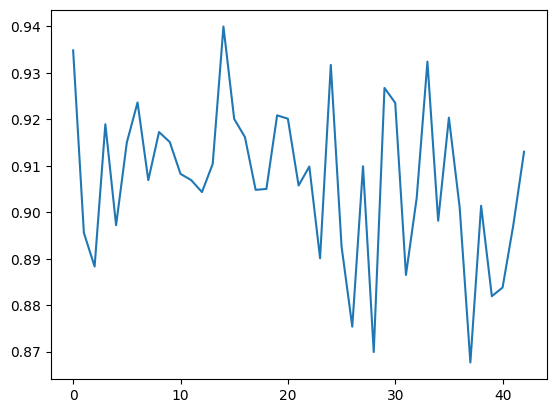

In [ ]:
print(f'Total number of epochs: {results[1].total_epochs}')
plt.plot(results[1].criterion_list)

In [ ]:
results[1].max_anomaly

2

In [ ]:
pd_dataset_test['Target'][0]

'regardshimselfasinsignificantasthe'

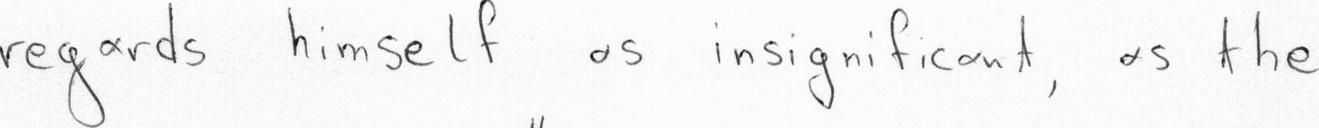

In [ ]:
check_picture1 = Image.open(pd_dataset_test["ImagePath"][0])
check_picture1

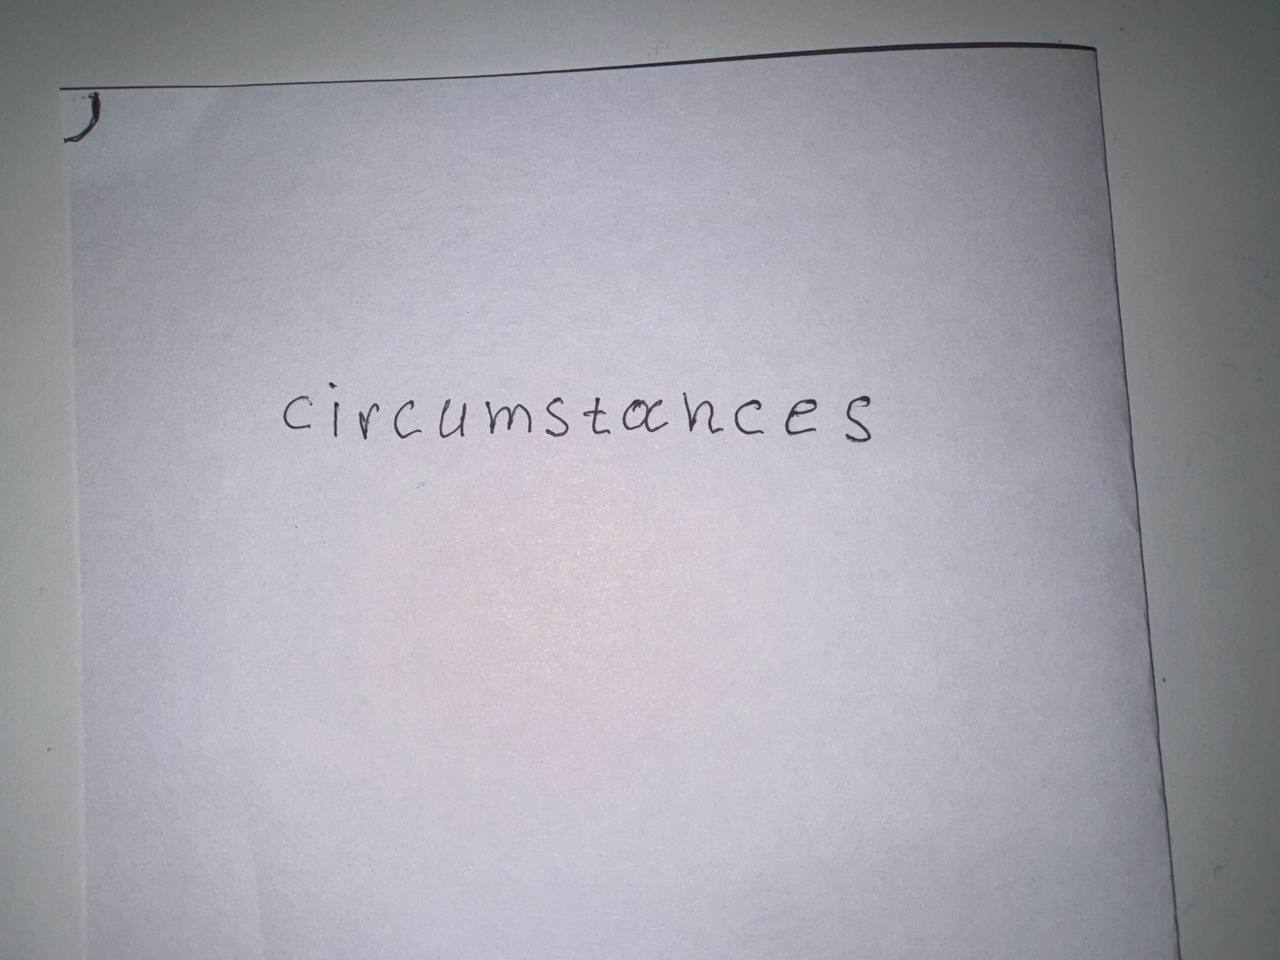

In [ ]:
check_picture2 = Image.open('/home/luchian/Downloads/check_circumstances.jpg')
check_picture2

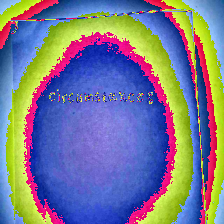

In [ ]:
functional.to_pil_image(resnet_trans(check_picture2))

In [ ]:
main_tokenizer = TorchDatasetTrain.tokenizer
main_tokenizer

PreTrainedTokenizerFast(name_or_path='', vocab_size=40, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<sos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
model.eval()

TRModel(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [ ]:
prediction = model_inference(pillow_picture=check_picture2, model=model, tokenizer=main_tokenizer, limit=100)
prediction

'strandasheacre21'

In [ ]:
test_metrics = get_metrics(TorchDatasetTest, model, main_tokenizer, model_inference)
print(f'CER: {test_metrics[0]}\nAccuracy: {test_metrics[1]}')

100%|██████████| 2915/2915 [10:29<00:00,  4.63it/s]

CER: 0.7580757292014608
Accuracy: 0.00034305317324185246


In [ ]:
print(len(pd_dataset_test))

2915


In [ ]:
len(TorchDatasetTest)

2915

In [ ]:
#saving tokenizer artifact for future inference
# with open('/home/luchian/prog/self_prog/Projects/TextRecognition/backend/model_tokenizer.pkl','wb') as pickle_file:
#     pickle.dump(TorchDatasetTrain.tokenizer,  pickle_file)

In [ ]:
#error analysis

In [ ]:
model.load_state_dict(torch.load('/home/luchian/all_data/ML_models_weights/28-10-2025_TextRec_200_60_weights_v1.0.pth'))

<All keys matched successfully>

In [ ]:
pd_dataset_train_preds = pd_dataset_train.copy()
pd_dataset_train_preds

,ImagePath,Target
0,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle
1,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle
2,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle
3,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle
4,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle
...,...,...
196,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings
197,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings
198,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings
199,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings


In [ ]:
pd_dataset_train_preds['Predictions'] = pd_dataset_train_preds['ImagePath'].apply(lambda x: model_inference(pillow_picture=Image.open(x), model=model, tokenizer=main_tokenizer, limit=300))

In [ ]:
pd_dataset_train_preds

,ImagePath,Target,Predictions
0,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle,vehicle
1,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle,vehicle
2,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle,vehicle
3,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle,vehicle
4,/home/luchian/all_data/datasets/Image_data.v3/...,vehicle,vehicle
...,...,...,...
196,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings,vehing
197,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings,booking
198,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings,bookings
199,/home/luchian/all_data/datasets/Image_data.v3/...,neelasprings,bouding


In [ ]:
# pd_dataset_train_preds.to_csv('/home/luchian/all_data/ML_models_artifacts/with_model_prediction_overfitted_200.csv', index=False)

In [ ]:
for row in range(pd_dataset_train_preds.shape[0]):
    main_row = pd_dataset_train_preds.iloc[row,:]
    print(f'Target: {main_row['Target']} | Prediction: {main_row['Predictions']}')

Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: vehicle | Prediction: vehicle
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xyzwv | Prediction: xyzwv
Target: xavier | Prediction: xavier
Target: xavier | Prediction: xavier
Target: xavier | Prediction: xavier
Target: xavier | Prediction: xavier
Target: xavier | Prediction: xavier
Target: xavier | Prediction: xavier
Target: xavier | Prediction: vavish
Target: xavier | Prediction:

In [ ]:
some_block = next(model.children())
some_block

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con